In [1]:
import sys
import importlib
import os
sys.path.append(os.path.abspath(".."))

import pipeline.io as io
import pipeline.data_handler as dh
import matplotlib.pyplot as plt



In [2]:
"""Plotting code to visual the dataframes as they go through the pipeline"""
def plot_lightcurve(df):
    plt.figure(figsize=(8, 5))

    plt.plot(df[0], df[1], '.', markersize=4)

    plt.xlabel("Time")
    plt.ylabel("Magnitude")
    plt.title("Lightcurve")
    plt.gca().invert_yaxis()  # important for astronomy magnitudes

    plt.tight_layout()
    plt.show()

In [3]:
print(dir(io))

['Path', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'create_file_list', 'csv_handler', 'json_handler', 'lightcurve_reader', 'multi_lightcurve_reader', 'pd', 'tab_handler', 'txt_handler', 'xml_handler']


In [4]:
valid_tab_path = '/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970305.tab'
valid_xml_path = '/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970203.xml'

In [5]:
data_valid_tab, metadata, code_valid_tab = io.lightcurve_reader(valid_tab_path)
print(data_valid_tab, code_valid_tab)

[             0       1
0  50512.79195  19.015
1  50512.86314  19.057
2  50512.91949  19.031] 0


In [6]:
data_valid_xml, metadata,code_valid_xml = io.lightcurve_reader(valid_xml_path)
print(data_valid_xml, code_valid_xml)

Reading of file: /Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970203.xml failed.
None -1


In [7]:
print(io.create_file_list('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999', 'tab', id_string='13651'))


files = io.create_file_list('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999', 'tab', id_string='13651')
print(files[0])
files_0 = [files[2]]

data, metadata, exit_status = io.multi_lightcurve_reader(files)
print(data)
print(len(files))
print(len(data))

[PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970209.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970224.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970226.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970131.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970301.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970303.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970302.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970307.tab'), PosixPath('/Users/smores/Downloads/gbo.ast-neo.ondrejov.lightcurves/data/ast_10000_99999/13651_19970305.tab'), 

In [8]:
importlib.reload(dh)


<module 'pipeline.data_handler' from '/Users/smores/Desktop/school/S26/computationalastro/Asteroid-Period-Finder/pipeline/data_handler.py'>

In [ ]:
data, metadata, exit_status = io.lightcurve_reader('/Users/smores/Desktop/school/S26/computationalastro/Asteroid-Period-Finder/data/ALCDEF/ALCDEF_50_Virginia_20260503_183833.txt')

In [ ]:
processed = dh.process_lightcurve(data, metadata, 'virginia')

In [57]:
dh.check_relative_mags(metadata[0])

True

In [58]:
import pipeline.fourier_engine as fe
import numpy as np

importlib.reload(fe)

frequencies, powers, fpeak = fe.lomb_scargle(processed['jd_corrected'], processed[1])

print(fpeak)

4.492454773412366


In [59]:
print(processed)
print((processed['jd_corrected'] - processed[0]).describe())

                 0         1  uncertainty  jd_corrected
0     2.455134e+06  0.108941        0.014  2.455134e+06
1     2.455134e+06  0.068949        0.014  2.455134e+06
2     2.455134e+06  0.076957        0.014  2.455134e+06
3     2.455134e+06  0.075968        0.014  2.455134e+06
4     2.455134e+06  0.048977        0.015  2.455134e+06
...            ...       ...          ...           ...
3377  2.455280e+06 -0.023469        0.032  2.455280e+06
3378  2.455280e+06 -0.004663        0.034  2.455280e+06
3379  2.455280e+06 -0.002762        0.028  2.455280e+06
3380  2.455280e+06 -0.018856        0.026  2.455280e+06
3381  2.455280e+06 -0.024050        0.033  2.455280e+06

[3382 rows x 4 columns]
count    3382.000000
mean       -0.010237
std         0.001438
min        -0.015034
25%        -0.011399
50%        -0.010032
75%        -0.009356
max        -0.008157
dtype: float64


               0      1  uncertainty
0   2.455134e+06 -2.925        0.014
1   2.455134e+06 -2.965        0.014
2   2.455134e+06 -2.957        0.014
3   2.455134e+06 -2.958        0.014
4   2.455134e+06 -2.985        0.015
..           ...    ...          ...
70  2.455134e+06 -3.099        0.022
71  2.455134e+06 -3.076        0.034
72  2.455134e+06 -3.007        0.025
73  2.455134e+06 -3.051        0.018
74  2.455134e+06 -3.028        0.012

[75 rows x 3 columns]
{'REVISEDDATA': 'FALSE', 'ALLOWSHARING': 'TRUE', 'SUBMITPDS': 'TRUE', 'LASTUPDATE': '2018-12-07 00:00:00', 'LCBLOCKID': '6', 'OBJECTNUMBER': '4', 'OBJECTNAME': 'Vesta', 'MPCDESIG': '', 'SESSIONDATE': '2009-10-29', 'SESSIONTIME': '14:41:00', 'CONTACTNAME': 'V. Reddy', 'CONTACTINFO': '[reddy@psi.edu]', 'OBSERVERS': 'V.Reddy,', 'FACILITY': '', 'MPCCODE': '', 'TELESCOPE': '0.35-m SCT', 'DETECTOR': 'FLI Dream Machine CCD', 'OBSLONGITUDE': '-158.066667', 'OBSLATITUDE': '+21.644444', 'EXPOSURE': '-99', 'EXPJD': 'MID', 'OBJECTRA': '09:

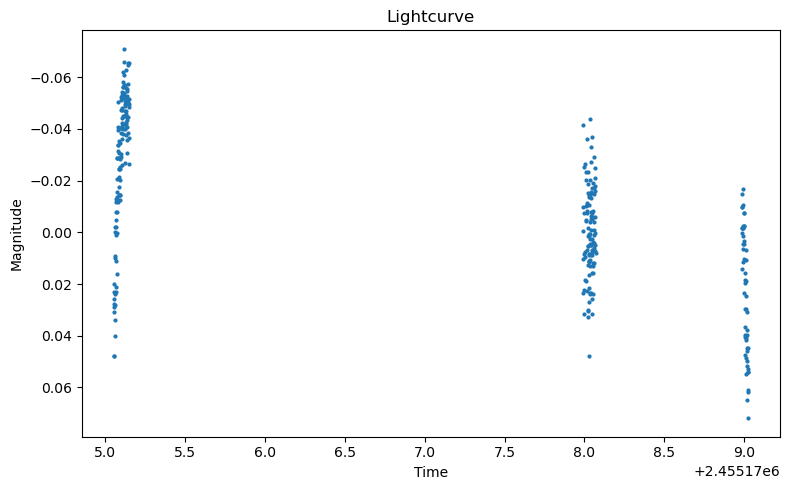

In [ ]:
print(data[0])
print(metadata[0])

print(metadata[0]['LTCAPP'])


plot_lightcurve(processed[:100])

Top 10 peaks:
Rank   Frequency (c/d)      Period (hr)     Power     
-------------------------------------------------------
1      4.4925               5.342           478.8013  
2      5.4941               4.368           477.4737  
3      4.4918               5.343           473.5304  
4      5.4934               4.369           472.7883  
5      4.4931               5.341           470.6560  
6      5.4948               4.368           469.4357  
7      5.4928               4.369           455.5075  
8      4.4911               5.344           454.4524  
9      4.4938               5.341           450.8199  
10     5.4955               4.367           449.4054  

Known double frequency: 1.4502 c/d (P = 16.55 hr)


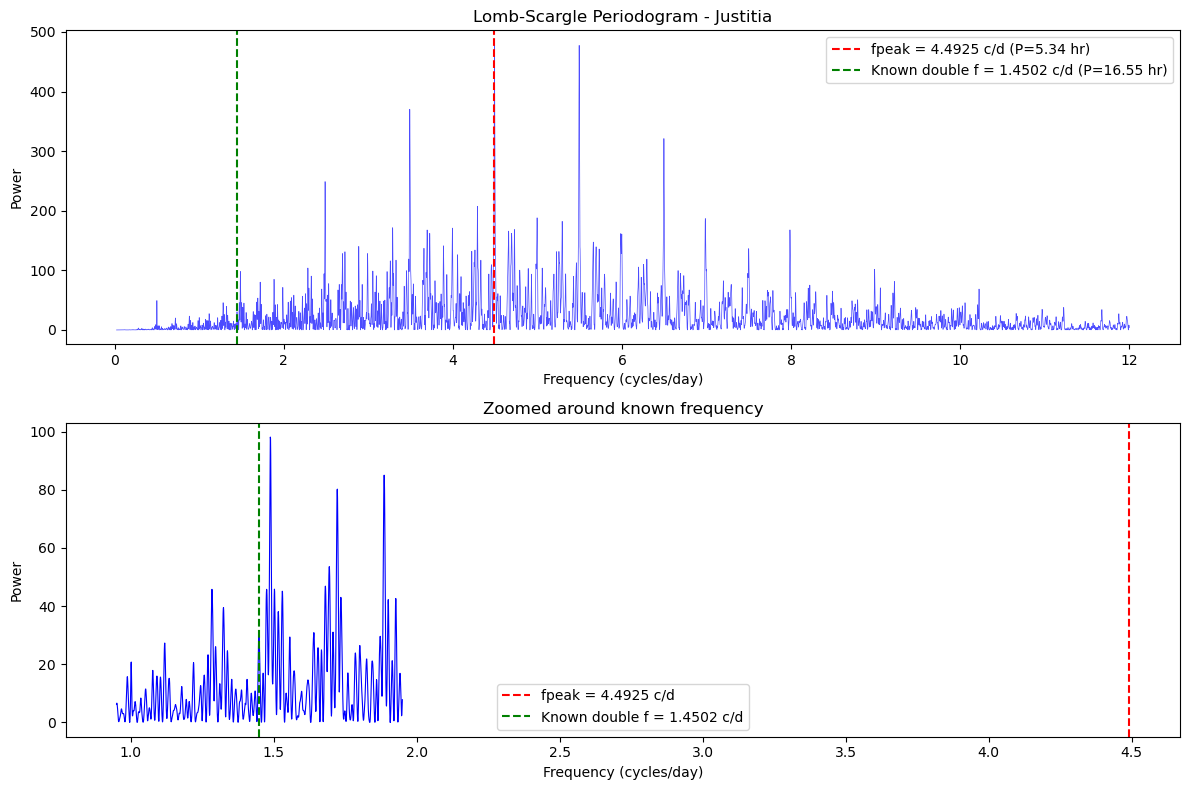

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Top 10 peaks
top10_idx = np.argsort(powers)[-10:][::-1]
print("Top 10 peaks:")
print(f"{'Rank':<6} {'Frequency (c/d)':<20} {'Period (hr)':<15} {'Power':<10}")
print("-" * 55)
for rank, idx in enumerate(top10_idx):
    f = frequencies[idx]
    p = 24 / f
    print(f"{rank+1:<6} {f:<20.4f} {p:<15.3f} {powers[idx]:<10.4f}")

# mark known frequency
f_known_double = 2 * (24/33.1)
print(f"\nKnown double frequency: {f_known_double:.4f} c/d (P = {24/f_known_double:.2f} hr)")

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Full periodogram
ax1.plot(frequencies, powers, 'b-', linewidth=0.5, alpha=0.7)
ax1.axvline(fpeak, color='red', linestyle='--', label=f'fpeak = {fpeak:.4f} c/d (P={24/fpeak:.2f} hr)')
ax1.axvline(f_known_double, color='green', linestyle='--', label=f'Known double f = {f_known_double:.4f} c/d (P={24/f_known_double:.2f} hr)')
ax1.set_xlabel('Frequency (cycles/day)')
ax1.set_ylabel('Power')
ax1.set_title('Lomb-Scargle Periodogram - Justitia')
ax1.legend()

# Zoomed in around the true frequency
f_center = f_known_double
f_window = 0.5
mask = (frequencies >= f_center - f_window) & (frequencies <= f_center + f_window)
ax2.plot(frequencies[mask], powers[mask], 'b-', linewidth=0.8)
ax2.axvline(fpeak, color='red', linestyle='--', label=f'fpeak = {fpeak:.4f} c/d')
ax2.axvline(f_known_double, color='green', linestyle='--', label=f'Known double f = {f_known_double:.4f} c/d')
ax2.set_xlabel('Frequency (cycles/day)')
ax2.set_ylabel('Power')
ax2.set_title('Zoomed around known frequency')
ax2.legend()

plt.tight_layout()
plt.show()

In [65]:
import pipeline.harmonic_logic as hl
importlib.reload(hl)


best_frot, period_hours, best_coeffs, is_double_peaked = hl.harmonic_logic(
    processed['jd_corrected'].values, 
    processed[1].values, 
    frequencies, 
    powers
)


Found 3 clusters, refining each...
  Cluster f=4.4925 c/d → frot=4.4929 c/d (P=5.342 hr), chi2=0.001454, double=False
  Cluster f=5.4941 c/d → frot=2.7473 c/d (P=8.736 hr), chi2=0.001524, double=True
  Cluster f=3.4908 c/d → frot=3.4911 c/d (P=6.875 hr), chi2=0.001574, double=False

Best rotation frequency: 4.492904 c/d
Best period: 5.3418 hours
Chi2 single harmonic: 0.001549
Chi2 double harmonic: 0.001454
Double peaked: False
